In [3]:
import pennylane as qml
from pennylane.qchem import one_particle, two_particle, observable
from pennylane import numpy as pnp

from pyscf import gto, scf, fci, ao2mo, cc
import numpy as np
import matplotlib.pyplot as plt

In [9]:
class RHFSpectralMomentGreenFunction:
    def __init__(self, mf):
        self.mf = mf
        self.mol = mf.mol

        self.nmo = mf.mo_coeff.shape[1]
        self.nelec = self.mol.nelectron
        self.n_spin_orbitals = 2 * self.nmo
        self.wires = list(range(self.n_spin_orbitals))
        self.nuclear_repulsion_energy = self.mol.energy_nuc()

        self.one_mo, self.two_mo = self.build_mo_integrals()
        self.qubit_hamiltonian = self.build_qubit_hamiltonian()
        self.Hmat = qml.matrix(self.qubit_hamiltonian, wire_order=self.wires)

        self.a, self.adag = self.build_fermionic_operators()

    def build_mo_integrals(self):
        one_ao = self.mf.get_hcore()
        two_ao = self.mol.intor("int2e_sph")

        C = self.mf.mo_coeff

        one_mo = C.T @ one_ao @ C

        two_mo = ao2mo.incore.full(two_ao, C)
        two_mo = np.swapaxes(two_mo, 1, 3)

        return one_mo, two_mo

    def build_qubit_hamiltonian(self):
        h1 = one_particle(self.one_mo)
        h2 = two_particle(self.two_mo)

        return observable(h1, h2, mapping="jordan_wigner")

    def pyscf_comparisons(self):
        outputs = {
            "hf_energy": self.mf.e_tot,
        }

        cisolver = fci.FCI(self.mol, self.mf.mo_coeff)
        fci_energy, fci_vector = cisolver.kernel()
        outputs["fci_energy"] = fci_energy
        outputs["fci_vector"] = fci_vector

        try:
            ccsdsolver = cc.CCSD(self.mf).run()
            outputs["ccsd_energy"] = ccsdsolver.e_tot
        except Exception as err:
            outputs["ccsd_energy"] = None
            outputs["ccsd_error"] = str(err)

        return outputs

    def build_fermionic_operators(self):
        a = []
        adag = []

        for p in self.wires:
            a_p = qml.jordan_wigner(qml.FermiA(p))
            adag_p = qml.jordan_wigner(qml.FermiC(p))

            a.append(qml.matrix(a_p, wire_order=self.wires))
            adag.append(qml.matrix(adag_p, wire_order=self.wires))

        return a, adag

    def run_vqe(self, max_steps=100, stepsize=0.1, initial_params=None):
        dev = qml.device("default.qubit", wires=self.n_spin_orbitals)

        hf_state = qml.qchem.hf_state(self.nelec, self.n_spin_orbitals)

        singles, doubles = qml.qchem.excitations(
            self.nelec,
            self.n_spin_orbitals,
        )

        s_wires, d_wires = qml.qchem.excitations_to_wires(
            singles,
            doubles,
        )

        @qml.qnode(dev)
        def energy_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.expval(self.qubit_hamiltonian)

        @qml.qnode(dev)
        def state_qnode(theta):
            qml.UCCSD(
                theta,
                wires=self.wires,
                s_wires=s_wires,
                d_wires=d_wires,
                init_state=hf_state,
            )
            return qml.state()

        n_params = len(singles) + len(doubles)

        if initial_params is None:
            theta = pnp.zeros(n_params, requires_grad=True)
        else:
            theta = pnp.array(initial_params, requires_grad=True)

        opt = qml.GradientDescentOptimizer(stepsize=stepsize)

        energy_history = []

        for step in range(max_steps):
            theta, electronic_energy = opt.step_and_cost(energy_qnode, theta)

            total_energy = electronic_energy + self.nuclear_repulsion_energy
            energy_history.append(total_energy)

            if step % 10 == 0:
                print(f"Step {step:3d} | Total VQE energy = {total_energy:.10f}")

        electronic_energy = energy_qnode(theta)
        total_energy = electronic_energy + self.nuclear_repulsion_energy
        psi = state_qnode(theta)

        return {
            "vqe_electronic_energy": electronic_energy,
            "vqe_total_energy": total_energy,
            "vqe_params": theta,
            "vqe_state": psi,
            "energy_history": energy_history,
            "singles": singles,
            "doubles": doubles,
        }

    def compute_moments(self, psi, nmom=1):
        E0_elec = np.vdot(psi, self.Hmat @ psi).real

        H_particle = self.Hmat - E0_elec * np.eye(2**self.n_spin_orbitals)
        H_hole = E0_elec * np.eye(2**self.n_spin_orbitals) - self.Hmat

        particle_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)
        hole_moments = np.zeros((nmom + 1, self.nmo, self.nmo), dtype=complex)

        for n in range(nmom + 1):
            Hp_n = np.linalg.matrix_power(H_particle, n)
            Hh_n = np.linalg.matrix_power(H_hole, n)

            for i in range(self.nmo):
                for j in range(self.nmo):
                    ia, ib = 2 * i, 2 * i + 1
                    ja, jb = 2 * j, 2 * j + 1

                    particle_moments[n, i, j] = (
                        np.vdot(psi, self.a[ia] @ Hp_n @ self.adag[ja] @ psi)
                        + np.vdot(psi, self.a[ib] @ Hp_n @ self.adag[jb] @ psi)
                    )

                    hole_moments[n, i, j] = (
                        np.vdot(psi, self.adag[ia] @ Hh_n @ self.a[ja] @ psi)
                        + np.vdot(psi, self.adag[ib] @ Hh_n @ self.a[jb] @ psi)
                    )

        return {
            "E0_electronic": E0_elec,
            "E0_total": E0_elec + self.nuclear_repulsion_energy,
            "hole_moments": np.real_if_close(hole_moments),
            "particle_moments": np.real_if_close(particle_moments),
        }

    def galitskii_migdal_energy(self, hole_moments):
        T0 = np.asarray(hole_moments[0], dtype=complex)
        T1 = np.asarray(hole_moments[1], dtype=complex)

        E_elec = 0.5 * (
            np.einsum("ij,ji->", T0, self.one_mo)
            + np.trace(T1)
        ).real

        return {
            "electronic": E_elec,
            "total": E_elec + self.nuclear_repulsion_energy,
        }

    @staticmethod
    def hermitize(A):
        return 0.5 * (A + A.conj().T)

    def block_hankel_auxiliary_representation(
        self,
        moments,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        moments = np.asarray(moments, dtype=complex)
        nmom_plus_1, nmo, _ = moments.shape

        if nblocks is None:
            nblocks = nmom_plus_1 // 2

        required_moments = 2 * nblocks

        if nmom_plus_1 < required_moments:
            raise ValueError(
                f"Need moments up to order {required_moments - 1} "
                f"for nblocks={nblocks}."
            )

        dim = nblocks * nmo

        S = np.zeros((dim, dim), dtype=complex)
        T = np.zeros((dim, dim), dtype=complex)

        for a in range(nblocks):
            for b in range(nblocks):
                S[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b]
                T[a*nmo:(a+1)*nmo, b*nmo:(b+1)*nmo] = moments[a + b + 1]

        S = self.hermitize(S)
        T = self.hermitize(T)

        svals, U = np.linalg.eigh(S)
        keep = svals > threshold

        if np.count_nonzero(keep) == 0:
            raise ValueError("Block overlap matrix has no eigenvalues above threshold.")

        svals_kept = svals[keep]
        U_kept = U[:, keep]

        S_inv_sqrt = U_kept @ np.diag(1.0 / np.sqrt(svals_kept))

        F = S_inv_sqrt.conj().T @ T @ S_inv_sqrt
        F = self.hermitize(F)

        eps, C = np.linalg.eigh(F)

        B = np.zeros((dim, nmo), dtype=complex)

        for a in range(nblocks):
            B[a*nmo:(a+1)*nmo, :] = moments[a]

        X = B.conj().T @ S_inv_sqrt @ C

        residues = []

        for k in range(len(eps)):
            x = X[:, k:k+1]
            residues.append(x @ x.conj().T)

        if verbose:
            print("moments shape:", moments.shape)
            print("nblocks:", nblocks)
            print("S dimension:", S.shape)
            print("S eigenvalues:", svals)
            print("kept:", np.count_nonzero(keep))

        return eps, residues, X

    def greens_function_from_moments(
        self,
        hole_moments,
        particle_moments,
        omega_grid,
        eta=0.05,
        nblocks=None,
        threshold=1e-10,
        verbose=False,
    ):
        eps_h, residues_h, Xh = self.block_hankel_auxiliary_representation(
            hole_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        eps_p, residues_p, Xp = self.block_hankel_auxiliary_representation(
            particle_moments,
            nblocks=nblocks,
            threshold=threshold,
            verbose=verbose,
        )

        omega_h = -np.abs(eps_h)
        omega_p = +np.abs(eps_p)

        G_w = np.zeros((len(omega_grid), self.nmo, self.nmo), dtype=complex)
        G_h_w = np.zeros_like(G_w)
        G_p_w = np.zeros_like(G_w)

        for iw, omega in enumerate(omega_grid):
            G_h = np.zeros((self.nmo, self.nmo), dtype=complex)
            G_p = np.zeros((self.nmo, self.nmo), dtype=complex)

            for pole, R in zip(omega_h, residues_h):
                G_h += R / (omega - pole + 1j * eta)

            for pole, R in zip(omega_p, residues_p):
                G_p += R / (omega - pole + 1j * eta)

            G_h_w[iw] = G_h
            G_p_w[iw] = G_p
            G_w[iw] = G_h + G_p

        A_h = -1.0 / np.pi * np.imag(np.trace(G_h_w, axis1=1, axis2=2))
        A_p = -1.0 / np.pi * np.imag(np.trace(G_p_w, axis1=1, axis2=2))
        A = A_h + A_p

        return {
            "omega": omega_grid,
            "G": G_w,
            "G_hole": G_h_w,
            "G_particle": G_p_w,
            "A": A,
            "A_hole": A_h,
            "A_particle": A_p,
            "hole_poles": eps_h,
            "particle_poles": eps_p,
            "physical_hole_poles": omega_h,
            "physical_particle_poles": omega_p,
            "hole_residues": residues_h,
            "particle_residues": residues_p,
            "hole_dyson_orbitals": Xh,
            "particle_dyson_orbitals": Xp,
        }

In [10]:
mol = gto.Mole(
    atom = 'H 0 0 0; H 0 0 1.4; H 0 0 2.8', 
    basis = 'sto-3g', # minimal basis set
    spin = 1 # singlet state
)

# perform Hartree-Fock calculation
mf = scf.RHF(mol)
mf.kernel() 

converged SCF energy = -1.40288679189723


Initialize <pyscf.gto.mole.Mole object at 0x11a1f2ad0> in <pyscf.scf.rohf.ROHF object at 0x11a1f2d50>


np.float64(-1.4028867918972296)


WARN: RCCSD method does not support ROHF method. ROHF object is converted to UHF object and UCCSD method is called.

E(UCCSD) = -1.496355876884338  E_corr = -0.09346908498710806
Step   0 | Total VQE energy = -1.4028867919
Step  10 | Total VQE energy = -1.4466919084
Step  20 | Total VQE energy = -1.4700507432
Step  30 | Total VQE energy = -1.4822511497
Step  40 | Total VQE energy = -1.4886524278
Step  50 | Total VQE energy = -1.4920567680
Step  60 | Total VQE energy = -1.4938958573
Step  70 | Total VQE energy = -1.4949053998
Step  80 | Total VQE energy = -1.4954690016
Step  90 | Total VQE energy = -1.4957897610
moments shape: (6, 3, 3)
nblocks: 3
S dimension: (9, 9)
S eigenvalues: [1.37338616e-07 1.60403704e-05 3.81854310e-04 2.89759589e-03
 4.27282819e-02 4.44813582e-02 2.70287758e-01 1.22694255e+00
 2.40496345e+00]
kept: 9
moments shape: (6, 3, 3)
nblocks: 3
S dimension: (9, 9)
S eigenvalues: [3.15160703e-07 2.45456933e-05 7.59241132e-04 2.29309204e-03
 4.53205782e-02 4.57276877e-02 

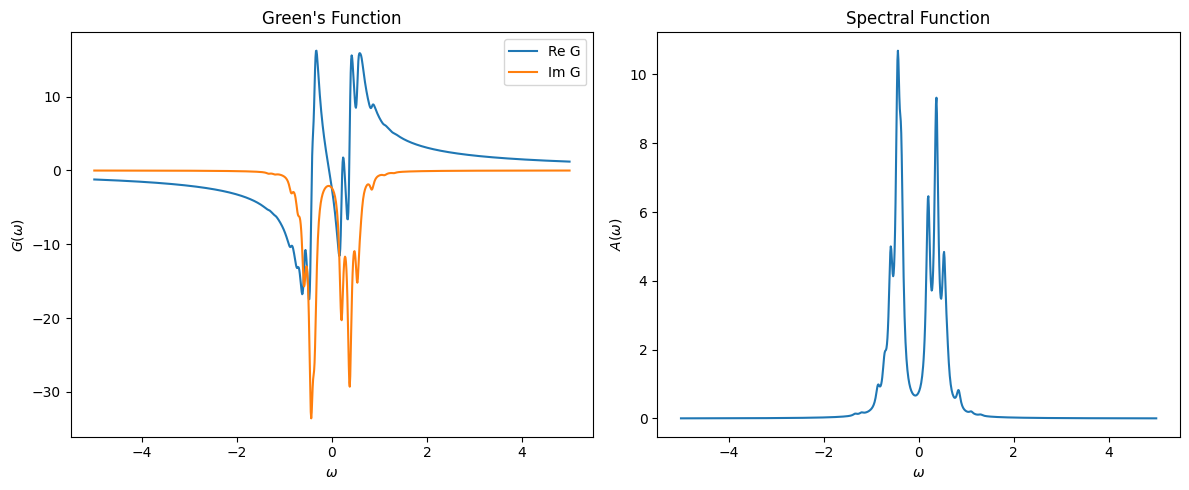

In [13]:
engine = RHFSpectralMomentGreenFunction(mf)

pyscf_outputs = engine.pyscf_comparisons()

vqe_outputs = engine.run_vqe(
    max_steps=100,
    stepsize=0.1,
) 

moments = engine.compute_moments(
    psi=vqe_outputs["vqe_state"],
    nmom=5,
)

hole_moments = moments["hole_moments"]
particle_moments = moments["particle_moments"]

gm = engine.galitskii_migdal_energy(hole_moments)

omega_grid = np.linspace(-5, 5, 1000)

gf_data = engine.greens_function_from_moments(
    hole_moments=hole_moments,
    particle_moments=particle_moments,
    omega_grid=omega_grid,
    eta=0.05,
    nblocks=3,
    verbose=True,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Green's function
G_trace = np.trace(
    gf_data["G"],
    axis1=1,
    axis2=2
)

axes[0].plot(
    gf_data["omega"],
    G_trace.real,
    label="Re G"
)

axes[0].plot(
    gf_data["omega"],
    G_trace.imag,
    label="Im G"
)

axes[0].set_xlabel(r"$\omega$")
axes[0].set_ylabel(r"$G(\omega)$")
axes[0].set_title("Green's Function")
axes[0].legend()

# Spectral function
axes[1].plot(
    gf_data["omega"],
    gf_data["A"]
)

axes[1].set_xlabel(r"$\omega$")
axes[1].set_ylabel(r"$A(\omega)$")
axes[1].set_title("Spectral Function")

plt.tight_layout()
plt.show()

In [14]:
gm

{'electronic': np.float64(-2.4409359628140614),
 'total': np.float64(-1.4959766575997757)}